# Industry Selection

First, we need to select an industry of stocks to run the mean-reversion strategy on. I started with the following industries as reasonable candidates for cluster mean reversion:

Industries to test:
- Regional Banks
- Insurance
- Real estate (REIT—Residential)
- Utilities

Each industry was screened with yfinance for US-listed names with sufficient market cap and volume. Exploratory hierarchical clustering — and later backtests — are documented in **`clustering.ipynb`**. That work was mostly to find a useful stock universe where the strategy might work.

After testing, Sharpe ratios were generally below 1 for banks, insurance, and utilities. **REIT—Residential** was the only sector that looked promising, so that is what we used for the final strategy in `backtesting.ipynb` (the full residential REIT universe, not a sub-cluster from the dendrogram).

In [92]:
import yfinance as yf
from yfinance import EquityQuery
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np

industries = [["Financial Services", "Banks—Regional"], ["Financial Services", "Insurance—Property & Casualty"], ["Utilities", "Utilities—Regulated Electric"], ["Real Estate", "REIT—Residential"]]


df_list = []

for industry in industries:
    query = EquityQuery("and", [
        EquityQuery("eq", ["region", "us"]),
        EquityQuery("eq", ["sector", industry[0]]),
        EquityQuery("is-in", ["industry"] + industry[1:]),
        EquityQuery('is-in', ["exchange", "NYQ", "NMS", "NGM", "NCM"]),
        EquityQuery("gte", ["intradaymarketcap", 1_000_000_000]),
        EquityQuery("gte", ["avgdailyvol3m", 500_000]),
    ])

    result = yf.screen(
        query,
        size=250,
        sortField="intradaymarketcap",
        sortAsc=False
    )
    quotes = result["quotes"]
    industry_tickers = [q["symbol"] for q in quotes]

    end_date = dt.datetime.now().strftime('%Y-%m-%d')
    start_date = pd.to_datetime(end_date) - pd.DateOffset(365*10)

    df = yf.download(
    tickers=industry_tickers,
    start=start_date,
    end=end_date
    )['Close']

    print('df size before cleanup: ', df.shape)

    min_days = int(0.95 * len(df))   # allow ~5% missing bars
    valid_tickers = df.columns[df.notna().sum() >= min_days]
    df = df[valid_tickers]

    print('df size after cleanup: ', df.shape)

    df_list.append(df)


[*********************100%***********************]  75 of 75 completed


df size before cleanup:  (2511, 75)
df size after cleanup:  (2511, 71)


[*********************100%***********************]  16 of 16 completed


df size before cleanup:  (2511, 16)
df size after cleanup:  (2511, 13)


[*********************100%***********************]  34 of 34 completed


df size before cleanup:  (2511, 34)
df size after cleanup:  (2511, 34)


[*********************100%***********************]  13 of 13 completed

df size before cleanup:  (2511, 13)
df size after cleanup:  (2511, 10)


In [93]:
for df in df_list:
    print(list(df.columns))

    # data cleanup
    for ticker in df.columns:
        info = yf.Ticker(ticker).get_info()

        # Ensure that all tickers are in appropriate exchanges
        if info.get("fullExchangeName") not in ["NasdaqCM", "NasdaqGS", "NYSE"]:
            print('NOT A VALID EXCHANGE: ', ticker, info.get("fullExchangeName"))


['ABCB', 'ASB', 'AUB', 'BANC', 'BBAR', 'BBD', 'BBT', 'BKU', 'BPOP', 'BSBR', 'BUSE', 'CBSH', 'CFFN', 'CFG', 'CFR', 'COLB', 'CVBF', 'DB', 'EWBC', 'FBP', 'FCF', 'FFBC', 'FFIN', 'FHB', 'FHN', 'FIBK', 'FITB', 'FLG', 'FNB', 'FULT', 'GBCI', 'GGAL', 'HAPN', 'HBAN', 'HDB', 'HOMB', 'HOPE', 'HWC', 'IBN', 'ITUB', 'KEY', 'LYG', 'MFG', 'MTB', 'NWBI', 'NWG', 'OCFC', 'ONB', 'OZK', 'PB', 'PFS', 'PNC', 'PNFP', 'RF', 'RNST', 'SBCF', 'SFNC', 'SSB', 'TFC', 'TFSL', 'TOWN', 'UBSI', 'UCB', 'UMBF', 'USB', 'VLY', 'WAFD', 'WAL', 'WBS', 'WSBC', 'ZION']
['AFG', 'ALL', 'CB', 'CINF', 'CNA', 'KMPR', 'L', 'ORI', 'PGR', 'RLI', 'SIGI', 'TRV', 'WRB']
['AEE', 'AEP', 'CIG', 'CMS', 'CNP', 'D', 'DTE', 'DUK', 'ED', 'EIX', 'ENIC', 'ES', 'ETR', 'EVRG', 'EXC', 'FE', 'FTS', 'HE', 'IDA', 'KEP', 'LNT', 'NEE', 'NGG', 'NWE', 'OGE', 'PCG', 'PEG', 'PNW', 'POR', 'PPL', 'SO', 'TXNM', 'WEC', 'XEL']
['AMH', 'AVB', 'CPT', 'ELS', 'EQR', 'IRT', 'MAA', 'SUI', 'UDR', 'UMH']


## Validating REIT—Residential

Before moving on, we check that stocks in **REIT—Residential** are positively correlated, which isa basic requirement for cluster mean reversion. The correlation matrix, heatmap, and scatter matrix below support this industry choice.


In [98]:
def scatter_matrix(stocks, figsize=(14, 14)):
    from pandas.plotting import scatter_matrix

    scatter_matrix(
        stocks,
        figsize=figsize,
        alpha=0.4,
        diagonal="hist",
    )
    plt.suptitle("Scatter matrix", y=1.02)
    plt.tight_layout()
    plt.show()



Average pairwise correlation (excl. diagonal): 0.78


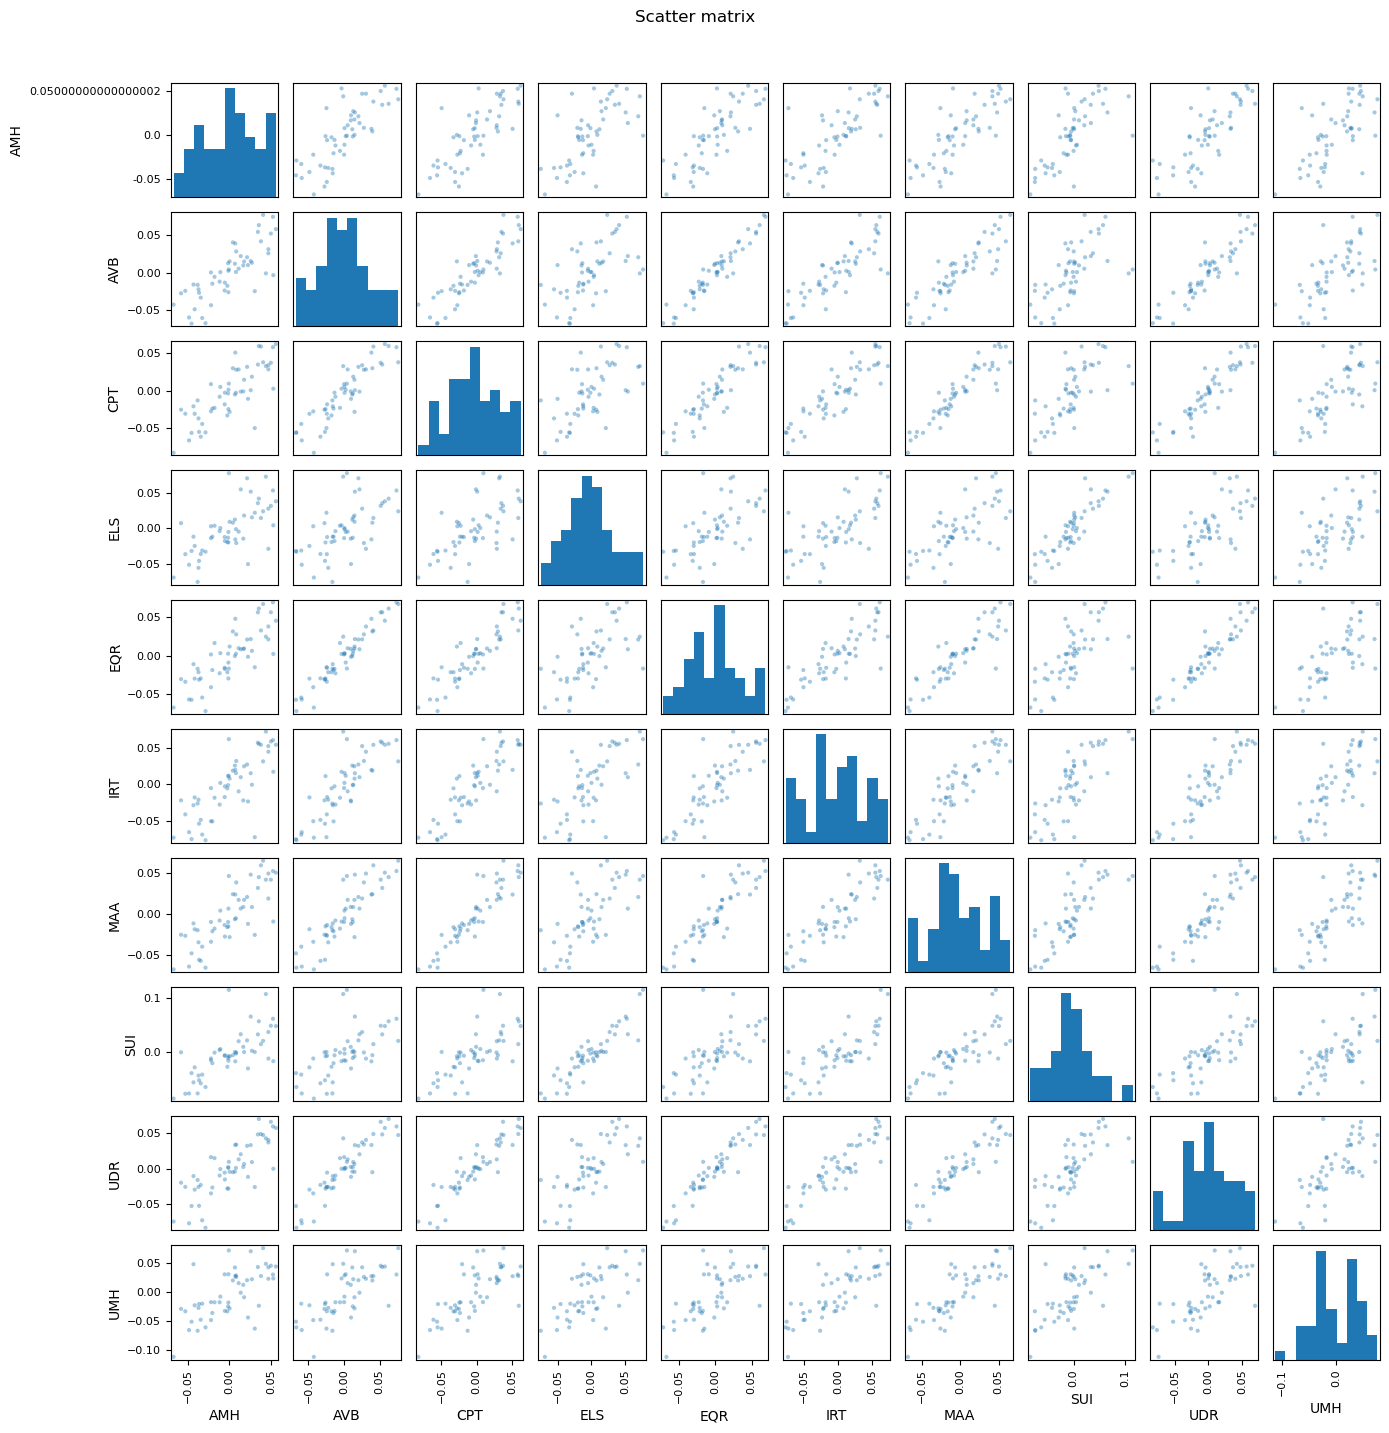

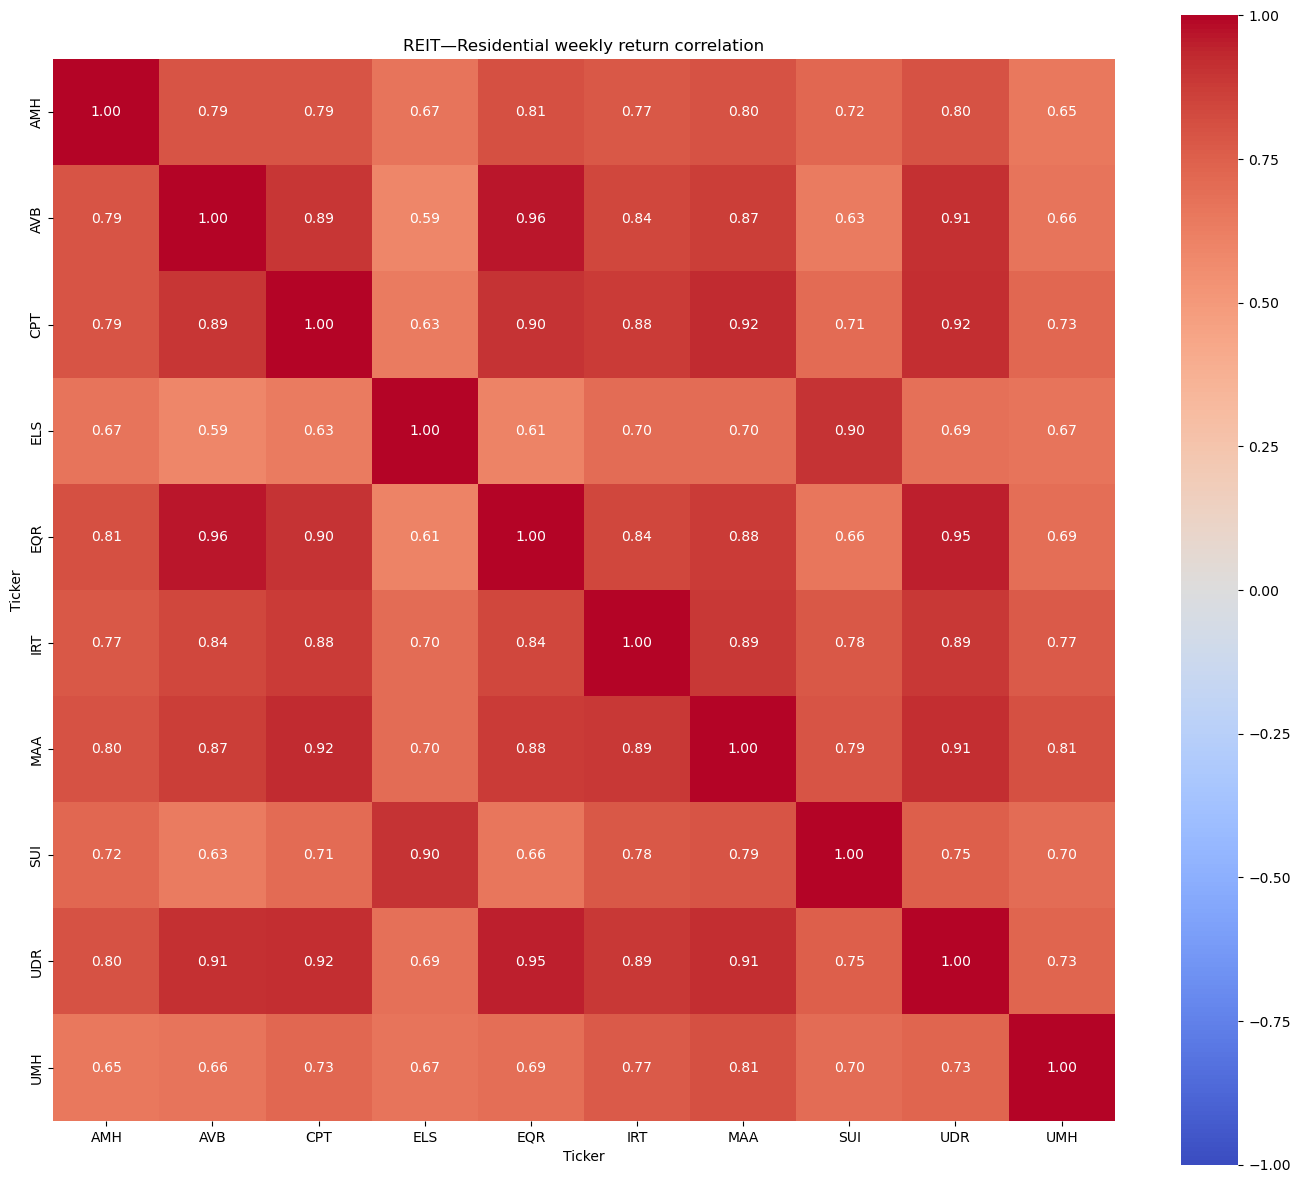

In [100]:
import seaborn as sns

reit_residential = df_list[3].copy()

# Use the same 1-year window as clustering.ipynb (one year before backtest)
end_date = reit_residential.index.max() - pd.DateOffset(years=3)
start_date = end_date - pd.DateOffset(years=1)
prices_window = reit_residential.loc[start_date:end_date]

weekly_prices = prices_window.resample("W-FRI").last()
weekly_returns = np.log(weekly_prices / weekly_prices.shift()).dropna()

corr = weekly_returns.corr()

mask = ~np.eye(len(corr), dtype=bool)
avg_corr = corr.where(mask).stack().mean()
print(f"\nAverage pairwise correlation (excl. diagonal): {avg_corr:.2f}")

scatter_matrix(weekly_returns)

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("REIT—Residential weekly return correlation")
plt.tight_layout()
plt.show()


## Outcome

The correlation heatmap and scatter matrix confirm that **REIT—Residential** names move together enough to justify mean reversion on this universe.

During the exploration phase, I have also implemented hierarchical clustering to find stocks that are highly correlated and group them into clusters, that in theory would work with my trading strategy. Although the best performing set of stocks was foudn simply by selecting the **REIT-Residential** sectors from Yahoo Finance, the exploratory code is still under **`clustering.ipynb`**.

**Final choice: REIT—Residential with tickers `["AMH", "AVB", "CPT", "ELS", "EQR", "IRT", "MAA", "SUI", "UDR", "UMH"]`**

In [101]:
FINAL_TICKERS = ["AMH", "AVB", "CPT", "ELS", "EQR", "IRT", "MAA", "SUI", "UDR", "UMH"]